**Step 1 — Set Up Your Environment**

In [1]:
pip install scikit-learn pandas numpy matplotlib seaborn

**Step 2 — Load and Explore the Dataset**

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the Iris dataset (built into scikit-learn, no download needed!)
iris = load_iris()

# Convert to DataFrame so it's easier to see
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target  # 0=Setosa, 1=Versicolor, 2=Virginica

# Explore the data
print(df.head())        # First 5 rows
print(df.shape)         # (150, 5)
print(df.describe())    # Statistics
print(df['species'].value_counts())  # 50 of each class

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
(150, 5)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000      

**Step 3 — Feature Scaling (The Gatekeeper Rule)**

In [3]:
from sklearn.preprocessing import StandardScaler

X = iris.data   # Features (4 columns)
y = iris.target # Labels (species)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - first row:", X[0])
print("After scaling - first row:", X_scaled[0])

Before scaling - first row: [5.1 3.5 1.4 0.2]
After scaling - first row: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]


**Step 4 — Train-Test Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    shuffle=True        # Remove order bias
)

print("Training samples:", len(X_train))  # Should be 120
print("Testing samples:", len(X_test))    # Should be 30

Training samples: 120
Testing samples: 30


**Step 5 — Apply the KNN Algorithm**

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate - Build the frame
model = KNeighborsClassifier(n_neighbors=5)

# Fit - Memorize the map (train)
model.fit(X_train, y_train)

# Predict - Apply logic (test)
predictions = model.predict(X_test)

print("Predictions:", predictions)
print("Actual:     ", y_test)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual:      [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


**Step 6 — Find the Optimal K (The Elbow)**

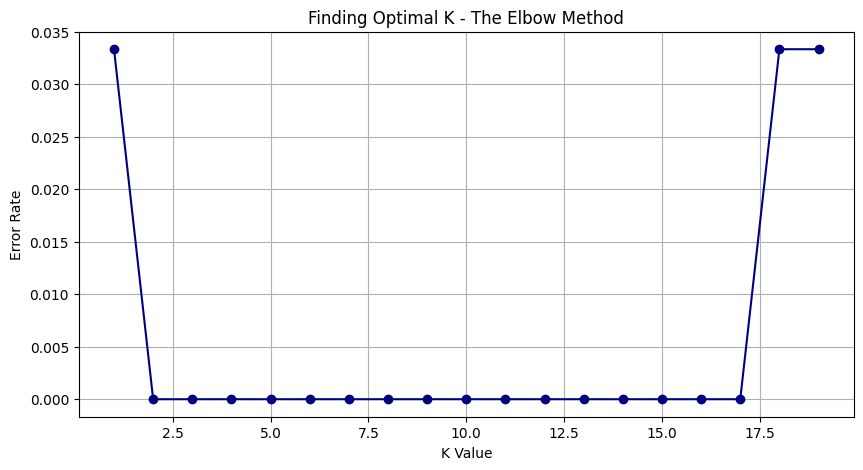

Best K: 2


In [6]:
# Test different K values to find the best one
error_rates = []

for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error = np.mean(preds != y_test)
    error_rates.append(error)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 20), error_rates, marker='o', color='navy')
plt.title('Finding Optimal K - The Elbow Method')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

# Pick the K with lowest error rate
best_k = error_rates.index(min(error_rates)) + 1
print("Best K:", best_k)

**Step 7 — Evaluate with Confusion Matrix & F1 Score**

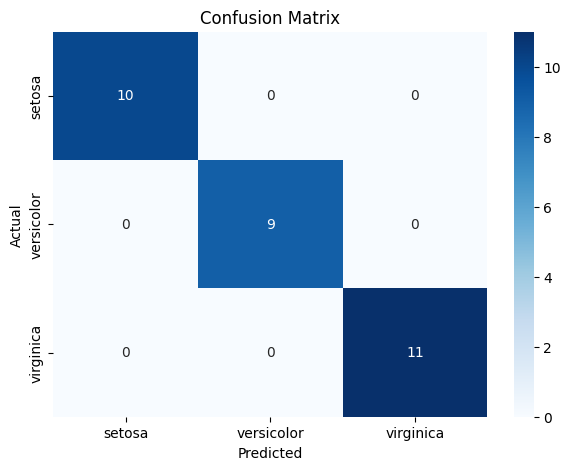

F1 Score: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# F1 Score
f1 = f1_score(y_test, predictions, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Full Report
print(classification_report(y_test, predictions, target_names=iris.target_names))

**Step 8 — Test with Brand New Data (Bonus!)**

In [8]:
# Predict a completely new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]  # Your custom measurements
new_flower_scaled = scaler.transform(new_flower)
prediction = model.predict(new_flower_scaled)
print("Predicted species:", iris.target_names[prediction[0]])

Predicted species: setosa
